In [61]:
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from calibration import lifetime_to_temperature_201112
from scipy.optimize import curve_fit
from scipy import stats
from matplotlib.backends.backend_pdf import PdfPages
from scipy.stats import sem

In [62]:
files_path = glob.glob('./2DG_RA/*26deg/*.csv')
files_path.sort()

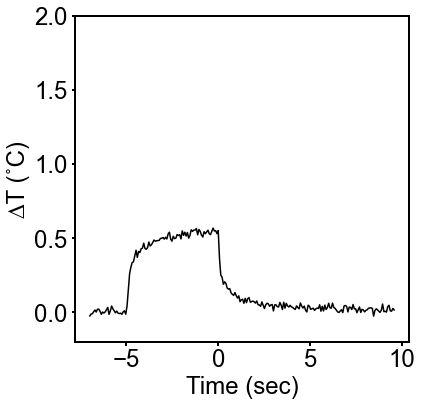

速い成分は0.142640sec
遅い成分は2.969501sec
割合は0.731865
時定数は2.641831


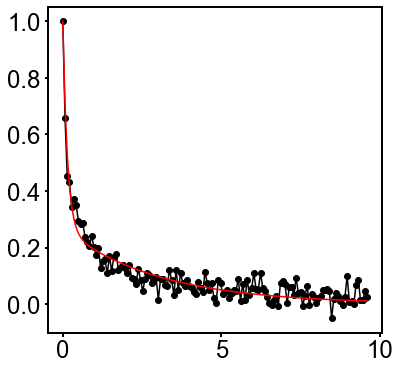

In [63]:
plt.figure(figsize = (6, 6))
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['xtick.major.width'] = 2.0
plt.rcParams['ytick.major.width'] = 2.0
plt.rcParams['axes.linewidth'] = 2.0
data_set_2DGRA = pd.DataFrame()

#データの平均化
average = np.zeros((1, 238))
for path in files_path:
    df = pd.read_csv(path, sep = '\t')
    relaxation_int = np.array(df.iloc[1:, 3], dtype = 'float32')
    relaxation = np.array(df.iloc[1:, 1], dtype = 'float32')
    diff = relaxation_int[:-1] - relaxation_int[1:]
    off_time = np.argmax(diff)
    extract = lifetime_to_temperature_201112(relaxation[off_time-100 : off_time+138])
    average += extract
    data_set_2DGRA = pd.concat([data_set_2DGRA, pd.DataFrame(extract)], axis = 1)
average_normal_2DGRA = average[0]/len(files_path)
average_normal_2DGRA = average_normal_2DGRA - np.mean(average_normal_2DGRA[:10])
time = [(i-100)*0.07 for i in range(len(average_normal_2DGRA))]
plt.tick_params(axis='both', direction = "out", labelsize = 24)
plt.plot(time, average_normal_2DGRA, color = 'Black')
plt.ylim(-0.2, 2.0)
plt.xlabel('Time (sec)', fontsize = 24)
plt.ylabel('∆T (˚C)', fontsize = 24)
plt.show()


#温度緩和の時定数の計算
time = [(i)*0.07 for i in range(len(average_normal_2DGRA[100:]))]
def relaxation(time, ratio, t1, t2):
    return ratio*np.exp(-time/t1) + (1-ratio)*np.exp(-time/t2)
result_2DGRA = curve_fit(relaxation, time ,average_normal_2DGRA[100:]/average_normal_2DGRA[100])[0]
print('速い成分は%fsec' % result_2DGRA[1])
print('遅い成分は%fsec' % result_2DGRA[2])
print('割合は%f' % result_2DGRA[0])
time_constant = (result_2DGRA[0]*(result_2DGRA[1]**2) + (1-result_2DGRA[0])*(result_2DGRA[2]**2))/(result_2DGRA[0]*result_2DGRA[1] + (1-result_2DGRA[0])*(result_2DGRA[2]))
print('時定数は%f' % time_constant)

plt.figure(figsize = (6, 6))
plt.tick_params(axis='both', direction = "out", labelsize = 24)
plt.plot(time, average_normal_2DGRA[100:]/average_normal_2DGRA[100], color = 'Black', marker = 'o')
plt.plot(time, relaxation(np.ravel(time), result_2DGRA[0], result_2DGRA[1], result_2DGRA[2]), color = 'red')
plt.show()

In [64]:
path = './liposome/Fig3f_liposome.csv'
df = pd.read_csv(path, header = None)
averaged_liposome = 0
data_set_liposome = pd.DataFrame()

for column in df:
    deltaT = -np.log(df[column])/0.0229
    deltaT= np.array(deltaT[34:234])
    averaged_liposome += deltaT
    data_set_liposome = pd.concat([data_set_liposome, pd.DataFrame(deltaT)], axis = 1)
    

averaged_liposome = pd.DataFrame(averaged_liposome/df.shape[1])[0]

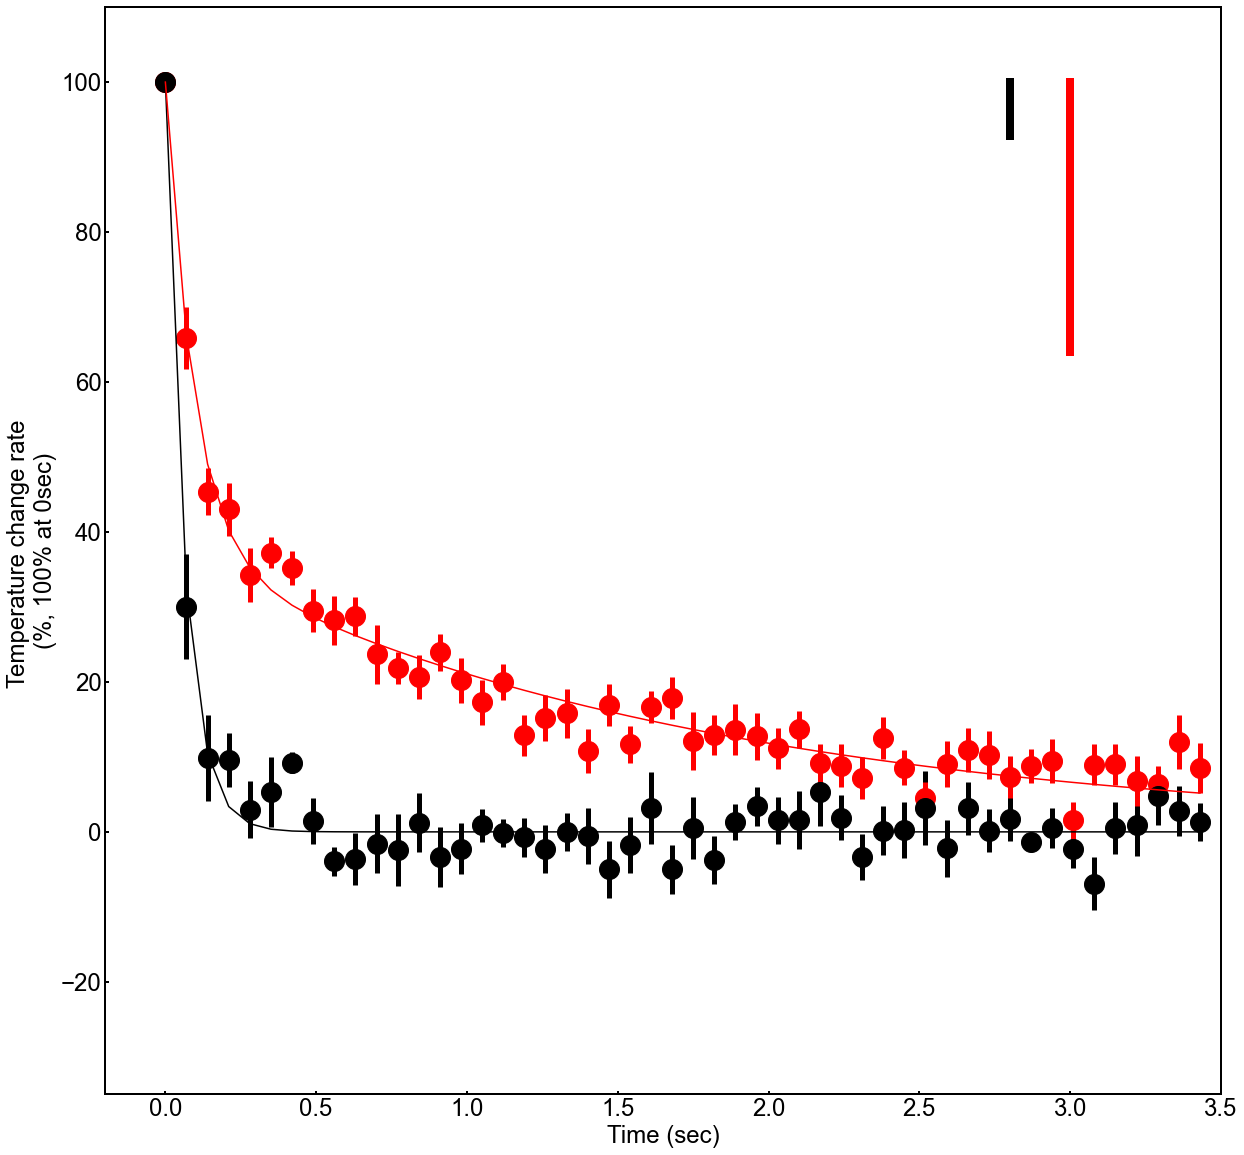

In [65]:
fig = plt.figure(figsize=(20, 20))
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['xtick.major.width'] = 2.0
plt.rcParams['ytick.major.width'] = 2.0
plt.rcParams['axes.linewidth'] = 2.0
plt.tick_params(axis='both', direction = "in", labelsize = 24)


#SEMの計算
data_set_2DGRA = data_set_2DGRA - np.mean(data_set_2DGRA.iloc[:10, :])
data_set_2DGRA = data_set_2DGRA/data_set_2DGRA.iloc[100, :]*100
sem_2DGRA = data_set_2DGRA.sem(axis = 1)

data_set_liposome = data_set_liposome/data_set_liposome.iloc[100, :]*100
sem_liposome = data_set_liposome.sem(axis = 1)


#1˚Cを示すバーを挿入
liposome_bar = [100- 20/averaged_liposome[100]*i/100 for i in range(100)]
liposome_bar_pos = [2.8 for i in range(len(liposome_bar))]
plt.plot(liposome_bar_pos, liposome_bar, linewidth = 8, color = 'black', linestyle = '-')

#1˚Cを示すバーを挿入
normal_bar = [100- 20/average_normal_2DGRA[100]*i/100 for i in range(100)]
normal_bar_pos = [3.0 for i in range(len(normal_bar))]
plt.plot(normal_bar_pos, normal_bar, linewidth = 8, color = 'red', linestyle = '-')



time = [i*0.07 for i in range(len(averaged_liposome[100:]))]
plt.errorbar(time[:50], averaged_liposome[100:150]*100/averaged_liposome[100], yerr = np.ravel(sem_liposome)[100:150], capsize=0, fmt='o', markersize=0, linewidth = 5, ecolor='black')
plt.errorbar(time[:50], average_normal_2DGRA[100:150]*100/average_normal_2DGRA[100], yerr = np.ravel(sem_2DGRA)[100:150], capsize=0, fmt='o', markersize=0, linewidth = 5, ecolor='red')
plt.plot(time[:50], average_normal_2DGRA[100:150]*100/average_normal_2DGRA[100], color = 'red', markersize = 20, marker = 'o', linewidth = 0)
plt.plot(time[:50], averaged_liposome[100:150]*100/averaged_liposome[100], color = 'black', markersize = 20, marker = 'o', linewidth = 0)
plt.xlim(-0.2, 3.5)
plt.ylim(-35, 110)
plt.xlabel('Time (sec)', fontsize = 24)
plt.ylabel('Temperature change rate \n(%, 100% at 0sec)', fontsize = 24)


#温度緩和の時定数の計算
def relaxation(time, ratio, t1, t2):
    return ratio*np.exp(-time/t1) + (1-ratio)*np.exp(-time/t2)

def relaxation_liposome(time, t1):
    return np.exp(-time/t1)

result_liposome = curve_fit(relaxation_liposome, time[:50], averaged_liposome[100:150]/averaged_liposome[100])[0]
result_5sec = curve_fit(relaxation, time[:50], average_normal_2DGRA[100:150]/average_normal_2DGRA[100])[0]

#fitting結果の図示
plt.plot(time[:50], relaxation_liposome(np.ravel(time[:50]), result_liposome[0])*100, color = 'black')
plt.plot(time[:50], relaxation(np.ravel(time[:50]), result_5sec[0], result_5sec[1], result_5sec[2])*100, color = 'red')

#pdfのセーブ
pp = PdfPages('./FigS17_2DGRA.pdf')
pp.savefig(fig)
pp.close()


#データの保存
pd.DataFrame(average_normal_2DGRA[100:150]*100/average_normal_2DGRA[100]).to_csv('normed_2DGRA.csv')
(sem_2DGRA)[100:150].to_csv('sem_2DGRA.csv')

In [66]:
#welchのt検定
sum_liposome = data_set_liposome.iloc[102:150].sum().values
sum_2DGRA = data_set_2DGRA.iloc[102:150].sum().values
stats.ttest_ind(sum_liposome, sum_2DGRA, equal_var = False)

Ttest_indResult(statistic=-13.03593423770078, pvalue=2.416979712133593e-10)

In [67]:
sem_liposome_bar = (sum_liposome*0.07).std(ddof = 1)/np.sqrt(len(sum_liposome))
sem_2DGRA_bar = (sum_2DGRA*0.07).std(ddof = 1)/np.sqrt(len(sum_2DGRA))

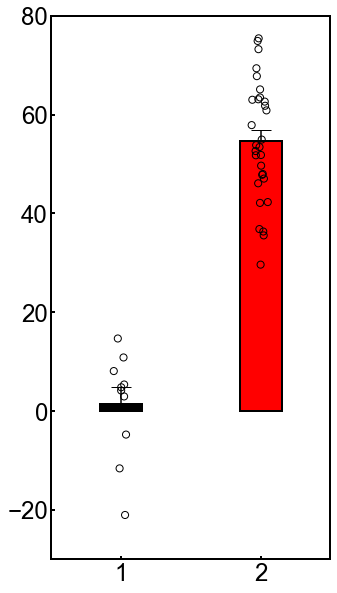

In [68]:
fig = plt.figure(figsize = (5, 10))
plt.tick_params(axis='both', direction = "in", labelsize = 24)
sum_liposome_ave = np.average(sum_liposome*0.07)
sum_2DGRA_ave = np.average(sum_2DGRA*0.07)
plt.bar(1, sum_liposome_ave, yerr = [[0], [sem_liposome_bar]], capsize = 10, ecolor = 'black', width=0.3, color=(0, 0, 0, 1), edgecolor='black', linewidth = 2, zorder = 1)
x = np.random.normal(1, 0.03, size=len(sum_liposome)) 
plt.scatter(x, sum_liposome*0.07, color='none', edgecolor='black', alpha = 1, s=50, zorder = 2)
plt.bar(2, sum_2DGRA_ave, yerr = [[0], [sem_2DGRA_bar]], capsize = 10, ecolor = 'black', width=0.3, color=(1, 0, 0, 1), edgecolor='black', linewidth = 2, zorder = 1)
x = np.random.normal(2, 0.03, size=len(sum_2DGRA)) 
plt.scatter(x, sum_2DGRA*0.07, color='none', edgecolor='black', alpha = 1, s=50, zorder = 2)

plt.ylim(-30, 80)
plt.xlim(0.5, 2.5)


#pdfのセーブ
pp = PdfPages('./FigS17_2DGRA_bar.pdf')
pp.savefig(fig)
pp.close()

#データの保存
pd.DataFrame(sum_2DGRA*0.07).to_csv('AUC_2DGRA.csv')

In [69]:
print(sum_2DGRA_ave)

54.59977


In [70]:
print(sem_2DGRA_bar)

2.220483734851282
